### Import

In [ ]:
# Libraries
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
import warnings

### Data Loading

In [7]:
# Data Loading
years = ["2012.h5", "2014.h5", "2016.h5", "2018.h5",
         "2020.h5", "2022.h5", "2024.h5", "2026.h5"]

with h5py.File(f"data/{years[0]}", "r") as data:
    lat = data["Latitude"][:]
    lon = data["Longitude"][:]

### Data Cleaning

In [8]:
# Data Cleaning
ozone_data = {}

for year in years:
    with h5py.File(f"data/{year}", 'r') as data:
        ozone = data['ColumnAmountO3'][:]
        
        ozone_masked = np.ma.masked_where(ozone < 0, ozone)
        
        ozone_data[int(year.split(".")[0])] = ozone_masked

# Exploratory Data Analysis

In this section, we explore the NASA OMPS-NPP ozone datasets to understand its structure and trends over the years 2012–2026.

Following is ozone data of one day from 2020.



In [9]:
pd.DataFrame(ozone_data[2020], index=lat, columns=lon).head(20)

,-179.5,-178.5,-177.5,-176.5,-175.5,-174.5,-173.5,-172.5,-171.5,-170.5,...,170.5,171.5,172.5,173.5,174.5,175.5,176.5,177.5,178.5,179.5
-89.5,293.403870,293.355560,293.244476,293.244476,293.244476,293.244476,293.244476,293.244476,293.244476,293.244476,...,298.893982,298.954620,298.974640,298.974640,298.974640,298.974640,298.555145,298.532837,298.532837,298.532837
-88.5,288.920410,288.969482,289.020050,289.020050,288.961334,288.915039,288.894592,288.888458,288.873901,288.919708,...,294.799286,294.709564,294.706451,294.671021,294.752167,294.752167,294.780518,294.846924,294.713165,294.721954
-87.5,289.189087,289.235352,289.231110,289.312561,289.348785,289.406525,289.426697,289.428162,289.513977,289.601624,...,292.031281,291.946198,291.944305,291.913910,291.834839,291.849091,291.846741,291.836548,291.836548,291.790405
-86.5,289.173950,289.123871,289.082764,289.083252,289.154816,289.279785,289.356171,289.138855,289.236359,289.207581,...,291.681702,291.708832,291.675232,291.879211,292.058868,292.036011,292.008484,291.946716,291.688446,291.554291
-85.5,290.280029,290.369202,290.273193,290.221710,290.241821,290.284119,290.268005,290.391418,290.183624,290.095001,...,292.415527,292.216705,291.816925,291.947968,292.373596,292.097778,291.672089,291.630798,291.361572,291.260742
-84.5,294.129669,294.230408,294.412323,294.573303,295.085785,295.215454,295.608093,295.715668,296.005676,296.481323,...,291.602081,291.253723,291.520477,291.758850,292.005585,292.018219,292.120789,292.675476,292.656433,292.122070
-83.5,297.259125,297.454895,297.469147,297.255096,297.547516,297.531982,297.834259,298.353149,298.486389,298.914490,...,295.049622,295.084869,295.445404,295.221649,295.216949,295.115143,295.116211,295.244720,294.900574,294.631653
-82.5,297.677429,297.810730,297.881653,297.859467,297.683777,297.602417,297.595856,297.843872,298.135956,298.683624,...,298.514374,298.254547,298.150330,298.077484,298.129852,298.057617,297.833282,297.951996,297.967499,297.905029
-81.5,297.675537,297.694366,297.588226,297.189362,297.046936,296.285004,295.840881,295.505585,295.336121,295.017700,...,302.685791,301.904663,301.459381,301.468781,300.472107,300.159912,299.879395,299.421936,299.166168,299.223511
-80.5,297.462830,297.265533,296.629883,296.165894,295.769897,295.131989,294.238586,293.596375,293.335663,292.603546,...,308.149506,307.981628,306.836395,304.817963,304.269379,302.375549,302.098083,301.396332,299.760529,299.175903


#### Global Ozone Distribution Visualization
This plot visualizes the **global distribution of ozone** of a day in the year 2020 using NASA OMPS-NPP data.  

- The **color scale (DU)** represents the ozone column amount in Dobson Units, with lower values indicating regions of **ozone depletion** and higher values indicating more abundant ozone.  
- We use a **pseudocolor mesh (`pcolormesh`)** to map the 2D ozone array across latitude and longitude.  
- **Coastlines and gridlines** provide geographic context for the spatial distribution.  

This visualization helps us **understand spatial patterns** and identify regions that may experience ozone depletion.

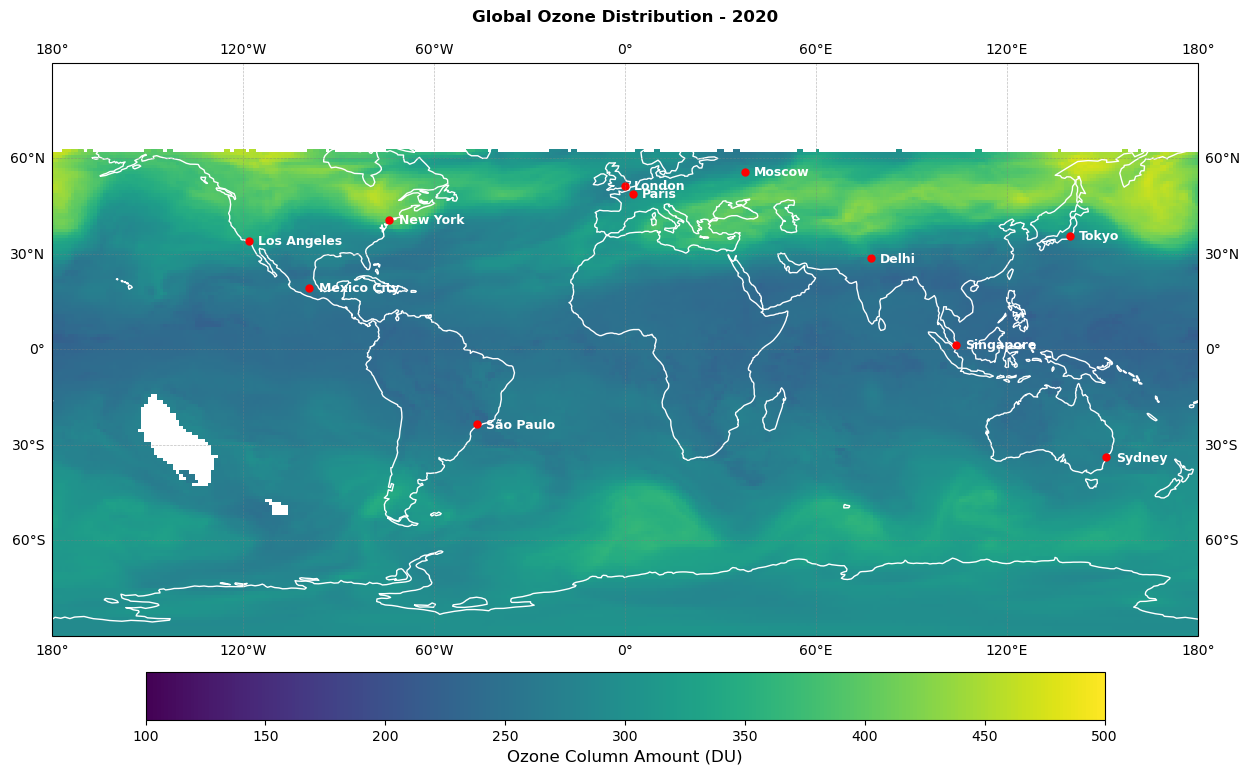

In [10]:
warnings.filterwarnings("ignore")
fig = plt.figure(figsize=(14, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ozone_2020 = ozone_data[2020]

im = ax.pcolormesh(lon, lat, ozone_2020, transform=ccrs.PlateCarree(), 
                    cmap='viridis', vmin=100, vmax=500)

ax.coastlines(color='white', linewidth=1)
cities = [
    (40.7128, -74.0060, 'New York'),
    (34.0522, -118.2437, 'Los Angeles'),
    (51.5074, -0.1278, 'London'),
    (35.6895, 139.6917, 'Tokyo'),
    (-33.8688, 151.2093, 'Sydney'),
    (28.6139, 77.2090, 'Delhi'),
    (55.7558, 37.6173, 'Moscow'),
    (19.4326, -99.1332, 'Mexico City'),
    (-23.5505, -46.6333, 'São Paulo'),
    (48.8566, 2.3522, 'Paris'),
    (1.3521, 103.8198, 'Singapore')
]
for city_lat, city_lon, city_name in cities:
    ax.plot(city_lon, city_lat, marker='o', color='red', markersize=5, transform=ccrs.PlateCarree())
    ax.text(city_lon + 3, city_lat, city_name, color='white', fontsize=9, weight='bold', transform=ccrs.PlateCarree(), ha='left', va='center')

ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')

cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7)
cbar.set_label('Ozone Column Amount (DU)', fontsize=12)

plt.title('Global Ozone Distribution - 2020', fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

#### City-Level Ozone Depletion Risk Assessment (2020)

This analysis evaluates **ozone depletion risk at major global cities** using satellite-derived ozone column data for the year **2020**.  
By mapping city coordinates to the nearest ozone grid points, we assess whether populated regions fall within **safe, warning, or severe depletion zones**.

In [11]:
SEVERE_DEPLETION = 220 
MODERATE_DEPLETION = 250 
NORMAL_MIN = 275  

ozone_2020 = ozone_data[2020]

def find_nearest_grid_point(city_lat, city_lon, lat, lon):
    """Find the nearest grid point index for a given city coordinate."""
    lat_idx = np.argmin(np.abs(lat - city_lat))
    lon_idx = np.argmin(np.abs(lon - city_lon))
    return lat_idx, lon_idx

city_coordinates_extended = {
    'New York, USA': (40.7128, -74.0060),
    'London, UK': (51.5074, -0.1278),
    'Tokyo, Japan': (35.6762, 139.6503),
    'Sydney, Australia': (-33.8688, 151.2093),
    'Mumbai, India': (19.0760, 72.8777),
    'São Paulo, Brazil': (-23.5505, -46.6333),
    'Cairo, Egypt': (30.0444, 31.2357),
    'Moscow, Russia': (55.7558, 37.6173),
    'Beijing, China': (39.9042, 116.4074),
    'Los Angeles, USA': (34.0522, -118.2437),
    'Cape Town, South Africa': (-33.9249, 18.4241),
    'Buenos Aires, Argentina': (-34.6037, -58.3816),
    'Melbourne, Australia': (-37.8136, 144.9631),
    'Paris, France': (48.8566, 2.3522),
    'Berlin, Germany': (52.5200, 13.4050),
    'Singapore': (1.3521, 103.8198),
    'Dubai, UAE': (25.2048, 55.2708),
    'Johannesburg, South Africa': (-26.2041, 28.0473),
    'Mexico City, Mexico': (19.4326, -99.1332),
    'Toronto, Canada': (43.6532, -79.3832)
}

danger_cities = []
warning_cities = []
safe_cities = []

for city, (city_lat, city_lon) in city_coordinates_extended.items():
    lat_idx, lon_idx = find_nearest_grid_point(city_lat, city_lon, lat, lon)
    ozone_value = ozone_2020[lat_idx, lon_idx]
    
    city_data = {
        'City': city,
        'Latitude': city_lat,
        'Longitude': city_lon,
        'Ozone (DU)': ozone_value
    }
    
    if ozone_value < SEVERE_DEPLETION:
        city_data['Status'] = 'SEVERE DEPLETION'
        danger_cities.append(city_data)
    elif ozone_value < MODERATE_DEPLETION:
        city_data['Status'] = 'MODERATE DEPLETION'
        warning_cities.append(city_data)
    elif ozone_value < NORMAL_MIN:
        city_data['Status'] = 'LOW (Warning)'
        warning_cities.append(city_data)
    else:
        city_data['Status'] = 'Normal'
        safe_cities.append(city_data)

print(f"\n{'='*70}")
print(f"OZONE DEPLETION ANALYSIS - YEAR 2020")
print(f"{'='*70}\n")

if danger_cities:
    print(f"SEVERE DEPLETION (<{SEVERE_DEPLETION} DU) - {len(danger_cities)} cities:")
    for city in danger_cities:
        print(f"  • {city['City']}: {city['Ozone (DU)']:.1f} DU")
    print()

if warning_cities:
    print(f"WARNING ZONE ({SEVERE_DEPLETION}-{NORMAL_MIN} DU) - {len(warning_cities)} cities:")
    for city in warning_cities:
        print(f"  • {city['City']}: {city['Ozone (DU)']:.1f} DU ({city['Status']})")
    print()

print(f"NORMAL LEVELS (>{NORMAL_MIN} DU) - {len(safe_cities)} cities")
print(f"\n{'='*70}\n")

all_cities = danger_cities + warning_cities + safe_cities
cities_df = pd.DataFrame(all_cities).sort_values('Ozone (DU)')
cities_df['Ozone (DU)'] = cities_df['Ozone (DU)'].round(1)


OZONE DEPLETION ANALYSIS - YEAR 2020

WARNING ZONE (220-275 DU) - 8 cities:
  • London, UK: 274.5 DU (LOW (Warning))
  • Mumbai, India: 240.2 DU (MODERATE DEPLETION)
  • São Paulo, Brazil: 249.7 DU (MODERATE DEPLETION)
  • Melbourne, Australia: 268.5 DU (LOW (Warning))
  • Singapore: 239.3 DU (MODERATE DEPLETION)
  • Dubai, UAE: 258.9 DU (LOW (Warning))
  • Johannesburg, South Africa: 248.4 DU (MODERATE DEPLETION)
  • Mexico City, Mexico: 255.9 DU (LOW (Warning))

NORMAL LEVELS (>275 DU) - 12 cities




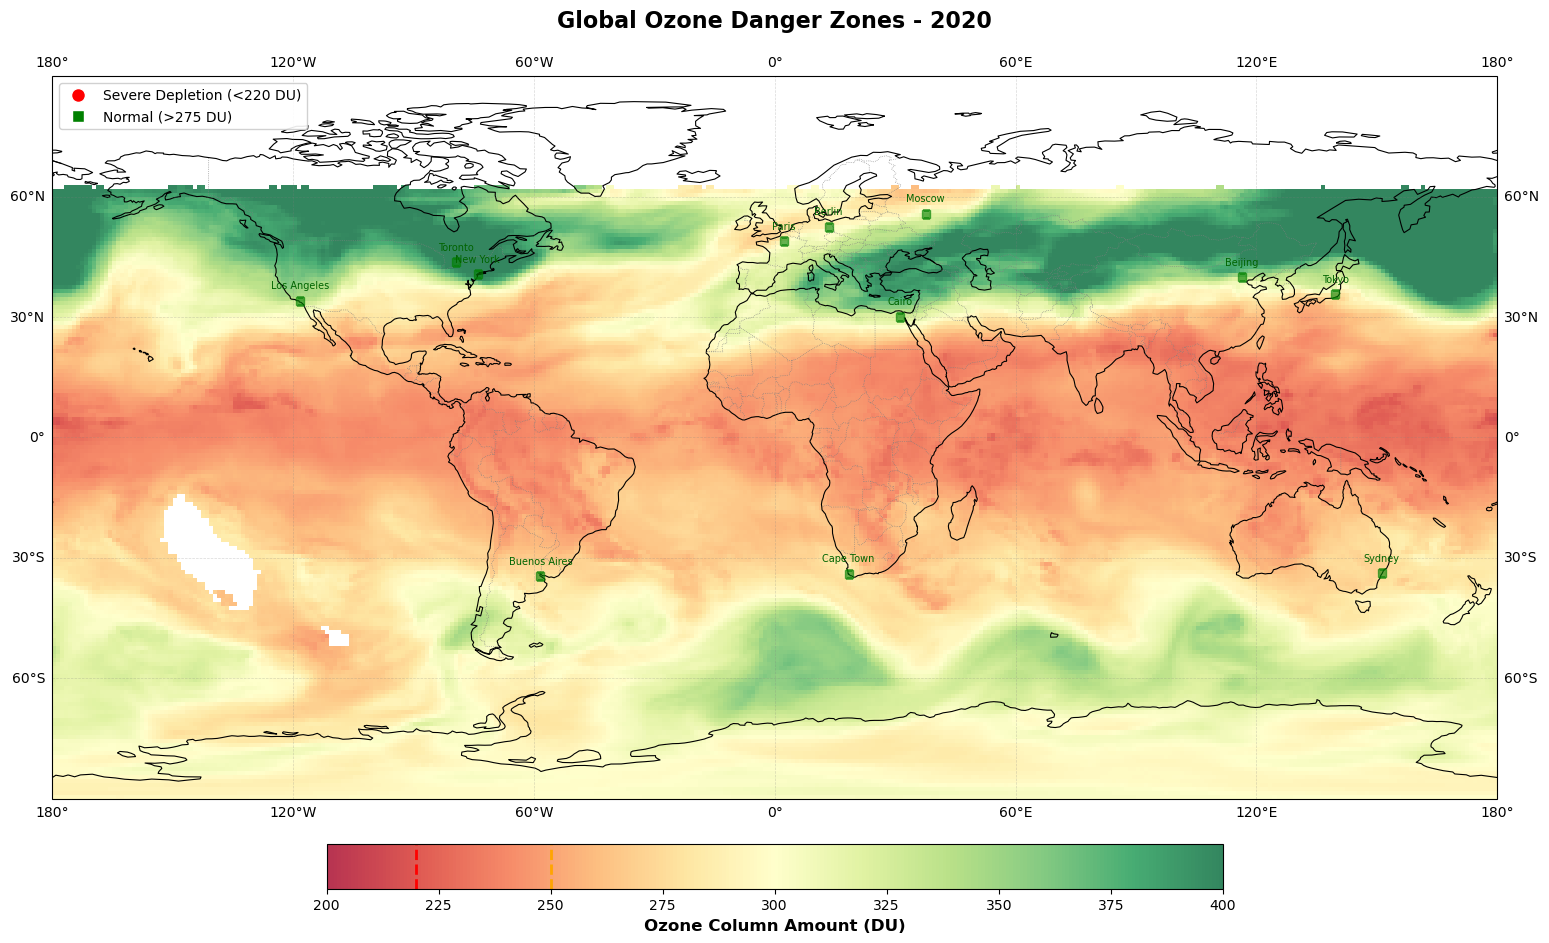

In [12]:
fig = plt.figure(figsize=(16, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

im = ax.pcolormesh(lon, lat, ozone_2020, transform=ccrs.PlateCarree(), 
                    cmap='RdYlGn', vmin=200, vmax=400, alpha=0.8)

ax.coastlines(color='black', linewidth=0.8)
ax.add_feature(ccrs.cartopy.feature.BORDERS, linestyle=':', color='gray', linewidth=0.5)
ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.3, linestyle='--')

for city_data in danger_cities:
    ax.plot(city_data['Longitude'], city_data['Latitude'], 
            marker='o', markersize=12, color='red', 
            transform=ccrs.PlateCarree(), zorder=5)
    ax.text(city_data['Longitude'], city_data['Latitude']+3, 
            city_data['City'].split(',')[0], 
            fontsize=8, ha='center', color='darkred', fontweight='bold',
            transform=ccrs.PlateCarree(), zorder=6)


for city_data in safe_cities:
    ax.plot(city_data['Longitude'], city_data['Latitude'], 
            marker='s', markersize=6, color='green', 
            transform=ccrs.PlateCarree(), zorder=5, alpha=0.6)
    ax.text(city_data['Longitude'], city_data['Latitude']+3, 
            city_data['City'].split(',')[0], 
            fontsize=7, ha='center', color='darkgreen',
            transform=ccrs.PlateCarree(), zorder=6)

cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.6)
cbar.set_label('Ozone Column Amount (DU)', fontsize=12, fontweight='bold')

cbar.ax.axvline(SEVERE_DEPLETION, color='red', linewidth=2, linestyle='--')
cbar.ax.axvline(MODERATE_DEPLETION, color='orange', linewidth=2, linestyle='--')

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', 
           markersize=10, label=f'Severe Depletion (<{SEVERE_DEPLETION} DU)'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='green', 
           markersize=8, label=f'Normal (>{NORMAL_MIN} DU)')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=10, framealpha=0.9)

plt.title(f'Global Ozone Danger Zones - 2020', 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

#### Global Average Ozone Over Years

The table below summarizes the **global mean ozone levels** for each year in our dataset (2012–2026).  

- The **Global Average Ozone (DU)** is calculated by taking the mean of the 2D ozone array (`ColumnAmountO3`) across all latitudes and longitudes.  
- This provides a **high-level view** of ozone trends over time, showing periods of depletion and recovery.

In [13]:
avg_ozone = [np.mean(ozone_data[y]) for y in sorted(ozone_data.keys())]
pd.DataFrame({
    "Year (January)": sorted(ozone_data.keys()),
    "Global Avg Ozone (DU)": avg_ozone
})

,Year (January),Global Avg Ozone (DU)
0,2012,286.491809
1,2014,286.746449
2,2016,286.054663
3,2018,290.272511
4,2020,293.674976
5,2022,283.024776
6,2024,287.340872
7,2026,290.129362


#### Global Average Ozone Trend (2012–2024)

This line plot shows the **yearly global average ozone levels** from 2012 to 2024.  

- The **y-axis** represents the ozone column amount in **Dobson Units (DU)**, and the **x-axis** represents the year.  
- Each **marker** shows the global mean ozone for that year, while the **line connects the trends** over time.  
- **Gridlines** and clear labels make it easier to read year-to-year variations.

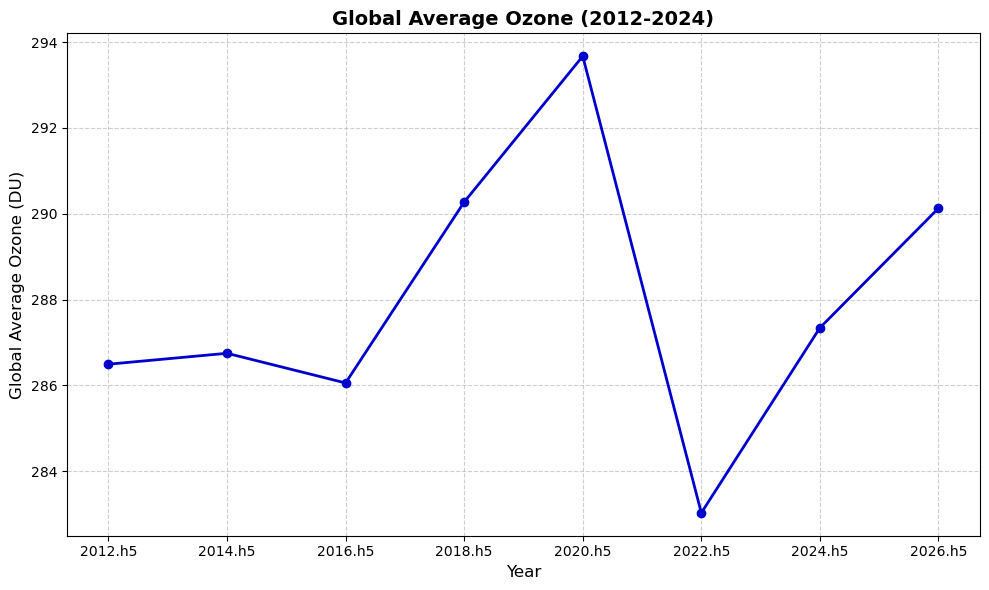

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(years, avg_ozone, marker="o", color="mediumblue", linewidth=2)
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Global Average Ozone (DU)", fontsize=12)
ax.set_title("Global Average Ozone (2012-2024)", fontsize=14, fontweight="bold")
ax.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

#### City-Wise Ozone Analysis (Interactive)

In this section, we analyze **ozone column concentration at major global cities** using satellite-based gridded ozone data.

##### City & Year Selection
- You can **select a specific year** using a dropdown.
- You can **select multiple cities** using checkboxes.
- This makes the analysis **interactive and flexible**, allowing comparison across locations and years.

##### Methodology
- Each city is defined by its **latitude and longitude**.
- Since satellite ozone data is stored on a **fixed latitude–longitude grid**, the exact city coordinates may not exist in the dataset.
- To handle this, we:
  - Find the **nearest grid point** to each city’s coordinates.
  - Extract the ozone value at that grid location for the selected year.
- Ozone values are reported in **Dobson Units (DU)**. 

This approach provides a **realistic estimate of ozone exposure** for major cities using global satellite observations.

#### Select Year and Cities

In [15]:
import json as _hex_json

selected_year = _hex_json.loads("2018")

In [16]:
import json as _hex_json

selected_cities = _hex_json.loads("[\"Moscow, Russia\",\"Sydney, Australia\",\"London, UK\"]")

#### Ozone Amount

In [17]:
city_coordinates = {
    'New York, USA': (40.7128, -74.0060),
    'London, UK': (51.5074, -0.1278),
    'Tokyo, Japan': (35.6762, 139.6503),
    'Sydney, Australia': (-33.8688, 151.2093),
    'Mumbai, India': (19.0760, 72.8777),
    'São Paulo, Brazil': (-23.5505, -46.6333),
    'Cairo, Egypt': (30.0444, 31.2357),
    'Moscow, Russia': (55.7558, 37.6173),
    'Beijing, China': (39.9042, 116.4074),
    'Los Angeles, USA': (34.0522, -118.2437)
}

def find_nearest_grid_point(target_lat, target_lon, lats, lons):
    """Find the nearest grid point to the target coordinates"""
    lat_diff = np.abs(lats - target_lat)
    lon_diff = np.abs(lons - target_lon)
    
    lat_idx = np.argmin(lat_diff)
    lon_idx = np.argmin(lon_diff)
    
    return lat_idx, lon_idx

results = []
for city in selected_cities:
    city_lat, city_lon = city_coordinates[city]
    lat_idx, lon_idx = find_nearest_grid_point(city_lat, city_lon, lat, lon)
    
    ozone_value = ozone_data[selected_year][lat_idx, lon_idx]
    
    results.append({
        'City': city,
        'Latitude': city_lat,
        'Longitude': city_lon,
        'Ozone (DU)': f"{ozone_value:.2f}"
    })

result_df = pd.DataFrame(results)
print(f"\n{'='*60}")
print(f"Ozone Column Amount for {selected_year}")
print(f"{'='*60}\n")
print(result_df.to_string(index=False))
print(f"\n{'='*60}")
print("Results show the ozone amount (Dobson Units) at selected city locations.")


Ozone Column Amount for 2018

             City  Latitude  Longitude Ozone (DU)
   Moscow, Russia   55.7558    37.6173     285.12
Sydney, Australia  -33.8688   151.2093     284.92
       London, UK   51.5074    -0.1278     356.35

Results show the ozone amount (Dobson Units) at selected city locations.


# Ozone Concentration Prediction

In this section, we extend the analysis beyond historical observations and **predict future ozone column concentrations** using past satellite data.

### Objective
The goal of this prediction is to:
- Identify **long-term trends** in global ozone levels
- Estimate how ozone concentration may change in the **near future**
- Support environmental monitoring and policy awareness

### Data Used
- NASA OMPS-NPP ozone datasets
- Ozone concentration measured in **Dobson Units (DU)**

### Prediction Approach
- A **time-series regression model** is applied to historical ozone data
- The model learns the relationship between **year and average ozone concentration**
- Future ozone values are predicted by extrapolating this learned trend

### Results
- The model produces predicted ozone values for upcoming years
- Predictions are visualized alongside historical data for easy comparison
- The trend indicates whether ozone levels are **increasing, decreasing, or stabilizing**

In [18]:
year_list = [2012, 2014, 2016, 2018, 2020, 2022, 2024, 2026]
mean_ozone_by_year = []

for year in year_list:
    mean_val = np.mean(ozone_data[year])
    mean_ozone_by_year.append(mean_val)

mean_ozone_by_year = np.array(mean_ozone_by_year)

In [19]:
from sklearn.linear_model import LinearRegression

X = np.array(year_list).reshape(-1, 1)
y = mean_ozone_by_year.reshape(-1, 1)

model = LinearRegression()
model.fit(X, y)

predicted_2027 = model.predict([[2027]])[0][0]

print(f"Predicted mean ozone for 2027: {predicted_2027:.2f} DU")
print(f"Trend: {model.coef_[0][0]:.4f} DU/year")
print(f"R² score: {model.score(X, y):.4f}")

Predicted mean ozone for 2027: 289.05 DU
Trend: 0.1354 DU/year
R² score: 0.0412


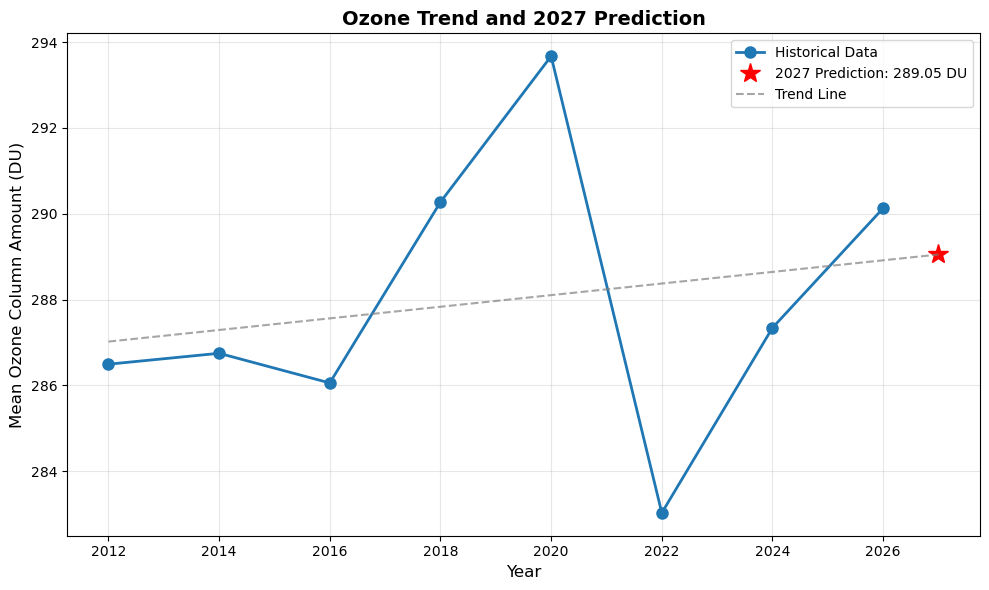

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(year_list, mean_ozone_by_year, 'o-', label='Historical Data', markersize=8, linewidth=2)
ax.plot(2027, predicted_2027, 'r*', markersize=15, label=f'2027 Prediction: {predicted_2027:.2f} DU')

years_extended = np.array(year_list + [2027]).reshape(-1, 1)
trend_line = model.predict(years_extended)
ax.plot(years_extended, trend_line, '--', color='gray', alpha=0.7, label='Trend Line')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Mean Ozone Column Amount (DU)', fontsize=12)
ax.set_title('Ozone Trend and 2027 Prediction', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()